In [1]:
# from sqlalchemy import create_engine
import pandas as pd 
import joblib
import matplotlib.pyplot as plt 
import json

In [2]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import precision_score, \
                            recall_score, f1_score, \
                            roc_auc_score, roc_curve, \
                            confusion_matrix , auc

# Getting data for Database

In [3]:
# #server is down, so no worries (this credentials will fail, use yours)
# username = 'postgres'
# password = 'kulVsK3Y8qNtbg2K8mbX'
# host_name = 'containers-us-west-86.railway.app'
# port = 7888
# db_name = 'railway'

# conn_str = 'postgresql://{}:{}@{}:{}/{}'.format(username, password, host_name, port, db_name)
# engine = create_engine(conn_str)
# query = 'select * from prediction;'

In [4]:
# data_server = pd.read_sql_query(query, engine)

In [5]:
# data_server['predicted_outcome'].value_counts()

In [6]:
# data_server.to_csv('data/data_server2.csv',index = False)

# Data exploration 

In [10]:
data = pd.read_csv('data/data_server')
data.head()

,id,observation_id,observation,predicted_outcome,outcome
0,5,1558a55e-3df2-4665-8beb-0f0c5eaa0408,"{""observation_id"": ""1558a55e-3df2-4665-8beb-0f...",False,False
1,6,eeb891e3-3913-4590-82a9-dc23c212dceb,"{""observation_id"": ""eeb891e3-3913-4590-82a9-dc...",False,True
2,7,898d6606-c55b-4a54-9480-f967beaff1cf,"{""observation_id"": ""898d6606-c55b-4a54-9480-f9...",False,False
3,8,3ff08b3c-c1fc-4c9f-97fe-470cf3a61cef,"{""observation_id"": ""3ff08b3c-c1fc-4c9f-97fe-47...",False,False
4,9,73d7c589-7605-42ab-9c5c-d0fbb897adb0,"{""observation_id"": ""73d7c589-7605-42ab-9c5c-d0...",True,False


In [11]:
data = data.set_index('id').reset_index(drop= True )

In [12]:
data.head()

,observation_id,observation,predicted_outcome,outcome
0,1558a55e-3df2-4665-8beb-0f0c5eaa0408,"{""observation_id"": ""1558a55e-3df2-4665-8beb-0f...",False,False
1,eeb891e3-3913-4590-82a9-dc23c212dceb,"{""observation_id"": ""eeb891e3-3913-4590-82a9-dc...",False,True
2,898d6606-c55b-4a54-9480-f967beaff1cf,"{""observation_id"": ""898d6606-c55b-4a54-9480-f9...",False,False
3,3ff08b3c-c1fc-4c9f-97fe-470cf3a61cef,"{""observation_id"": ""3ff08b3c-c1fc-4c9f-97fe-47...",False,False
4,73d7c589-7605-42ab-9c5c-d0fbb897adb0,"{""observation_id"": ""73d7c589-7605-42ab-9c5c-d0...",True,False


# data distro

In [13]:
data['outcome'].value_counts()

False    3136
True      884
Name: outcome, dtype: int64

# Evaluate API model

In [14]:
y_true = data['outcome']
y_pred = data['predicted_outcome']

In [15]:
# y_true.to_csv('data/y_true',index=False)

In [16]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score ,f1_score
precision = precision_score(y_true=y_true, y_pred=y_pred)
recall = recall_score(y_true=y_true, y_pred=y_pred)
f1 = f1_score(y_true=y_true, y_pred=y_pred)

In [17]:
print(f'precision = {precision}')
print(f'recall = {recall}')
print("F1 score:", f1)


precision = 0.2737556561085973
recall = 0.2737556561085973
F1 score: 0.2737556561085973


<Figure size 100x200 with 0 Axes>

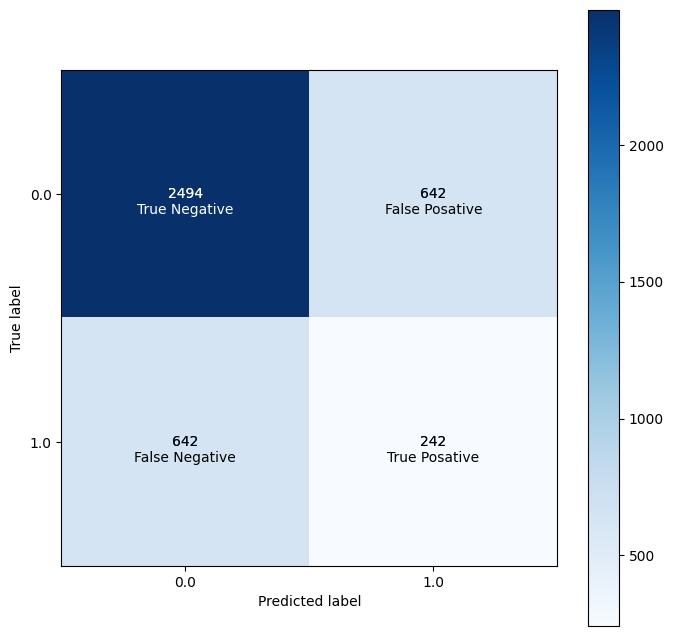

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
Pipe = joblib.load('pickles/diffmodel/adv_pipe.pickle')
plt.figure(figsize = (1,2)) # <-- just sets the figure size 
confmat = confusion_matrix(y_true=y_true, y_pred=y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=confmat,
                               display_labels=Pipe.classes_)

fig, ax = plt.subplots(figsize=(8, 8))
im = disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')

# add annotations to each square
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(j, i, f"\n{confmat[i, j]:d}\n"
                       f"{'True Negative' if i == j and i==0 else 'True Posative' if i== j and i ==1 else 'False Posative' if j > i else 'False Negative'}",
                ha="center", va="center", color="white" if confmat[i, j] > confmat.max() / 2 else "black")
plt.savefig('pics/confmat.png')
plt.show()

# compare with old data

In [19]:
data_cop = data.copy()
new_data = pd.DataFrame([json.loads(json_str) for json_str in data['observation']])
new_data['outcome'] = data_cop['outcome']
new_data['predicted_outcome'] = data_cop['predicted_outcome']
test_pred = new_data.drop(columns = ['outcome','predicted_outcome'])
old_data = pd.read_csv('data/train.csv')
new_data2 = pd.read_csv('data/data_filling_nans')

In [20]:
cop = new_data.copy()
cop['Date'] = pd.to_datetime(cop['Date'],infer_datetime_format=True)
cop.set_index('Date',inplace=True)
cop.index.max()

Timestamp('2022-05-13 22:58:26+0000', tz='UTC')

In [21]:
# new_data.to_csv('data/new_data.csv',index = False)

In [22]:
# test_pred.to_csv('data/test.csv',index=False)

In [23]:
test_pred['Age range'].value_counts()

over 34     1191
18-24       1149
25-34       1031
10-17        641
under 10       8
Name: Age range, dtype: int64

# checking data drift

In [24]:
test_pred['Date'] = pd.to_datetime(test_pred['Date'],infer_datetime_format=True)
test_pred['Date'].min() , test_pred['Date'].max()

(Timestamp('2022-01-01 00:35:00+0000', tz='UTC'),
 Timestamp('2022-05-13 22:58:26+0000', tz='UTC'))

In [25]:
columns_of_interest = ['Type','Part of a policing operation',
       'Latitude', 'Longitude', 'Gender', 'Age range', 'Officer-defined ethnicity','station']

In [26]:
# #     inverstigae columns disto
# for col in columns_of_interest : 
#     print(old_data[col].value_counts(normalize =True))
#     print('----------------------------------------------')

In [27]:
# #     inverstigae columns disto
# for col in columns_of_interest : 
#     print(new_data[col].value_counts(normalize=True))
#     print('----------------------------------------------')

# no new stations or object of search or Legislation

In [28]:
new_department_names = new_data['Object of search'].unique()
old_department_names = old_data['Object of search'].unique()

unknown_departments = [department for department in new_department_names if department not in old_department_names]
len(unknown_departments)

0

In [29]:
new_data['Part of a policing operation'] = new_data['Part of a policing operation'].astype('bool')
old_data['Part of a policing operation'] = old_data['Part of a policing operation'].astype('bool')

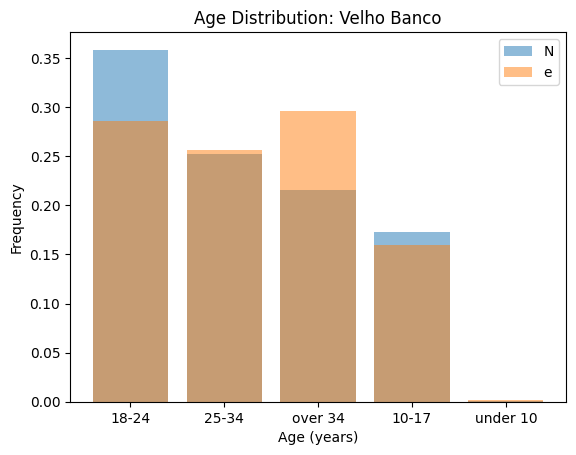

In [30]:
def generate_distribution_histogram(dataframe, 
                                    column_name, 
                                    title, x_axis_label, y_axis_label,
                                    label_name,
                                    number_bins = 15):
    """
    This function generates a histogram.
    Args:
        dataframe:
        column_name: String. Name of the column whose distribution we
        want to visualize.
        title: String. Title of the histogram.
        x_axis_label: String. X-axis label.
        y_axis_label: String. Y-axis label.
    Outputs:
        Histogram containing distribution for specific column column_name.
    """
    value_counts = dataframe[column_name].value_counts(normalize = True)

# Create the bar plot
    plt.bar(value_counts.index.astype(str), value_counts,alpha = 0.5)
    plt.xlabel(x_axis_label)
    plt.ylabel(y_axis_label)
    plt.title(title)
    
    # YOUR CODE HERE
    
    plt.legend(label_name,loc='upper right')
    axis = plt.gca();
    return axis
axis = generate_distribution_histogram(old_data, 'Age range',
                                title = 'Age Distribution: Velho Banco',
                                x_axis_label = 'Age (years)',
                                y_axis_label = 'Frequency',
                                label_name = 'Original data')
axis = generate_distribution_histogram(new_data, 'Age range',
                                title = 'Age Distribution: Velho Banco',
                                x_axis_label = 'Age (years)',
                                y_axis_label = 'Frequency',
                                label_name = 'New data')

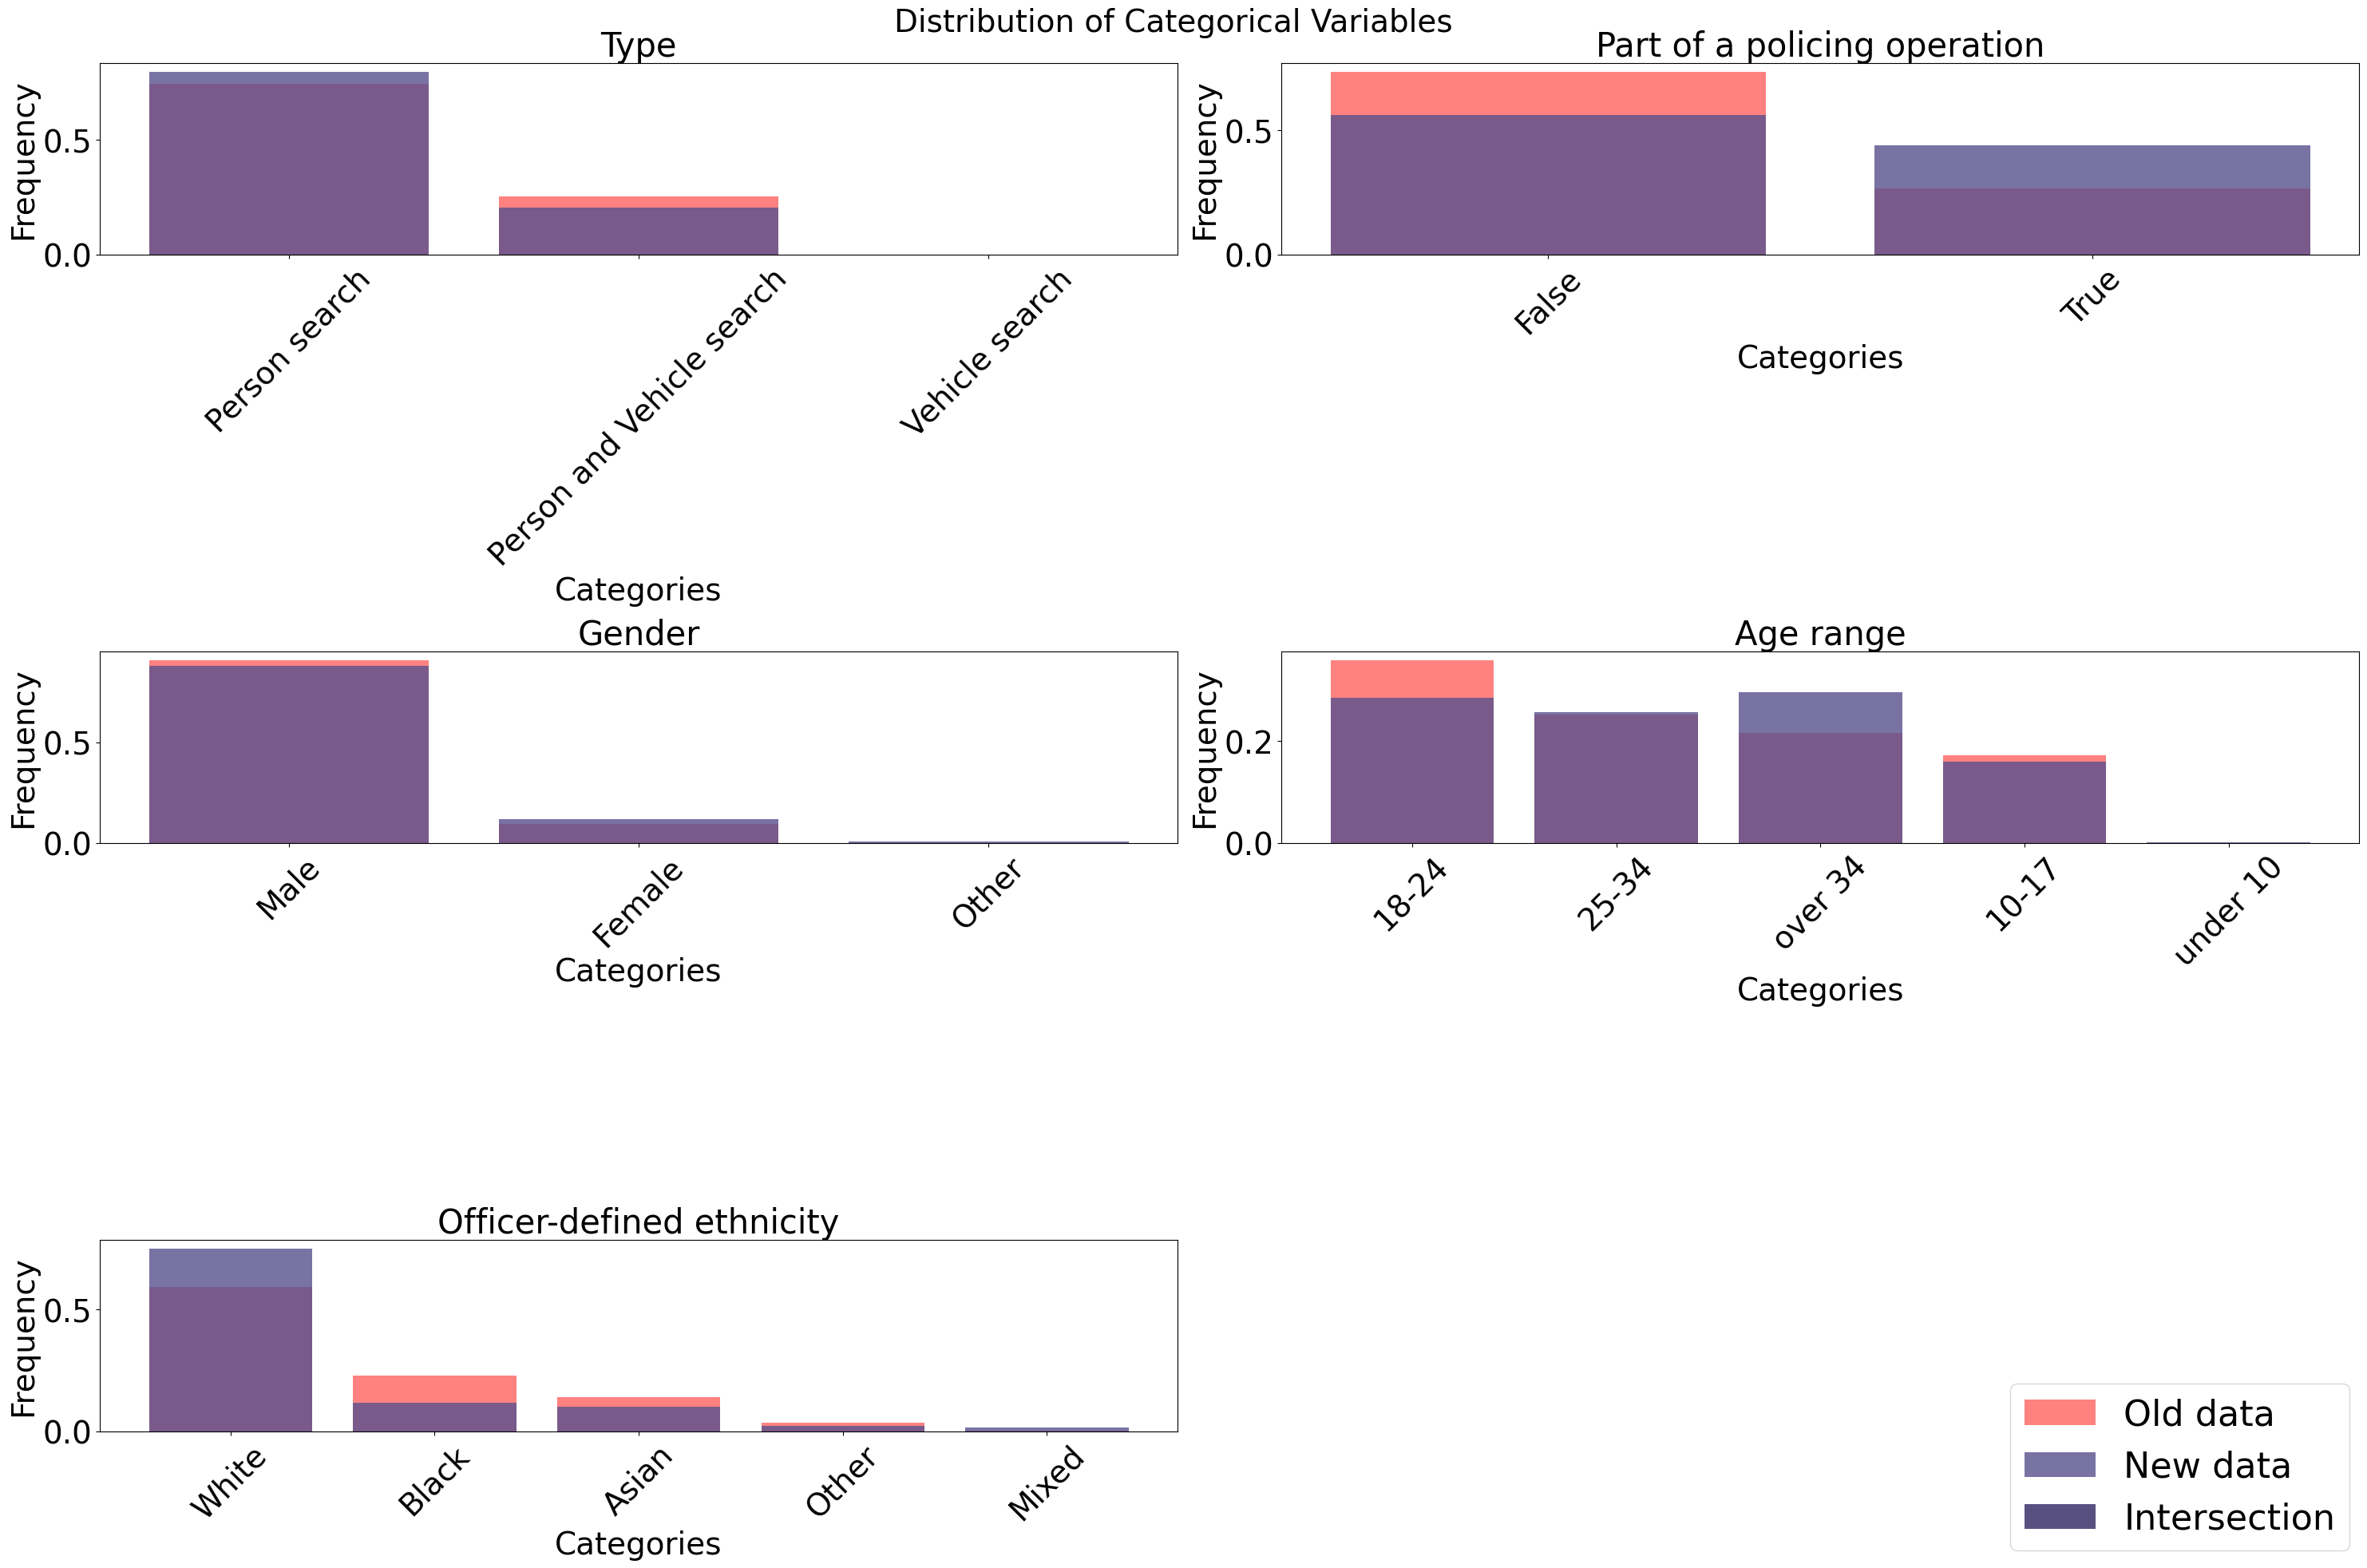

In [31]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def generate_multiple_histograms(dataframe1, dataframe2, columns, title, x_axis_label, y_axis_label):
    """
    This function generates multiple histograms for specified columns.
    Args:
        dataframe1: Pandas DataFrame for the first dataset.
        dataframe2: Pandas DataFrame for the second dataset.
        columns: List of column names whose distribution we want to visualize.
        title: String. Title of the plot.
        x_axis_label: String. X-axis label.
        y_axis_label: String. Y-axis label.
    Outputs:
        Subplots containing histograms for specified columns.
    """
    num_plots = len(columns)
    rows = int((num_plots + 1) / 2)  # Calculate the number of subplot rows

    fig, axes = plt.subplots(rows, 2, figsize=(30, 20), squeeze=False)
    fig.suptitle(title, fontsize=28)
    plt.subplots_adjust(hspace=0.5)  # Adjust vertical spacing between subplots

    plot_index = 0
    for i in range(rows):
        for j in range(2):
            if plot_index >= num_plots:
                # Remove any unused subplots
                fig.delaxes(axes[i, j])
            else:
                column_name = columns[plot_index]
                value_counts1 = dataframe1[column_name].value_counts(normalize=True)
                value_counts2 = dataframe2[column_name].value_counts(normalize=True)
                axes[i, j].bar(value_counts1.index.astype(str), value_counts1, color='#FF6361', alpha=0.8, label='Old data')
                axes[i, j].bar(value_counts2.index.astype(str), value_counts2, color='#58508D', alpha=0.8, label='New data')
                axes[i, j].set_xlabel(x_axis_label, fontsize=28)
                axes[i, j].set_ylabel(y_axis_label, fontsize=28)
                axes[i, j].set_title(column_name, fontsize=30)
                axes[i, j].tick_params(axis='x', rotation=45, labelsize=28)  # Rotate x-axis labels for better visibility and adjust font size
                axes[i, j].tick_params(axis='y', labelsize=28)  # Adjust font size of y-axis labels

                plot_index += 1

    # Custom legend
    legend_elements = [
        Patch(facecolor='#FF6361', alpha=0.8, label='Old data'),
        Patch(facecolor='#58508D', alpha=0.8, label='New data'),
        Patch(facecolor='#585080', label='Intersection')
    ]
    fig.legend(handles=legend_elements, loc='lower right',fontsize = 32)

    plt.tight_layout()
    plt.savefig('pics/distro')
    plt.show()


generate_multiple_histograms(old_data, new_data, ['Type','Part of a policing operation', 'Gender', 'Age range', 'Officer-defined ethnicity'],
                             title='Distribution of Categorical Variables',
                             x_axis_label='Categories',
                             y_axis_label='Frequency')


# Longitude and latitude distro

In [32]:
# import pandas as pd
# from shapely.geometry import Point
# import geopandas as gpd
# import matplotlib.pyplot as plt
# from geopandas import GeoDataFrame

# df = old_data[['Longitude', 'Latitude']]

# geometry = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
# gdf = GeoDataFrame(df, geometry=geometry)

# # Bounding box coordinates for the United Kingdom
# xmin, ymin = -10.854492, 49.823809
# xmax, ymax = 1.877441, 60.945484

# # Create a bounding box around the area of interest
# bbox = (xmin, ymin, xmax, ymax)  # Define the coordinates of the bounding box

# # Filter the world map to only include the area within the bounding box
# world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
# world = world.cx[xmin:xmax, ymin:ymax]  # Crop the world map to the specified bounding box

# # Plot the points within the cropped world map
# fig, ax = plt.subplots(figsize=(10, 6))

# world.plot(ax=ax, color='lightgray', edgecolor='gray')
# gdf.plot(ax=ax, marker='o', color='red', markersize=15)
# df = new_data[['Longitude', 'Latitude']]

# geometry = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
# gdf = GeoDataFrame(df, geometry=geometry)
# gdf.plot(ax=ax, marker='o', color='blue', markersize=10)
# # Set the x-axis and y-axis limits to zoom in on the points
# ax.set_xlim(xmin, xmax)
# ax.set_ylim(ymin, ymax)

# # Add title and labels
# plt.title("Location Data in the United Kingdom")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")

# # Add a legend
# ax.legend(["Old Data", "New Data"])

# # Display the plot
# plt.show()


In [33]:
# from scipy.stats import ks_2samp
# def get_ks_test(feature, training_df, new_df):
#     """
#     This function returns the result of the k-s statistic for the same feature in two datasets.
#     Args:
#         feature: feature name
#         training_df: dataframe used to train the model
#         new_df: dataframe with the new data
#     Outputs:
#         P-value of the K-S statistic for feature in training_df and new_df
#     """
#     #pvalue = ...
#     # YOUR CODE HERE
#     pvalue = ks_2samp(training_df[feature],new_df[feature]).pvalue
#     return pvalue

# ks_test_dict = {}
# for x in test_pred.drop(columns= ['observation_id','Date','Part of a policing operation','Legislation']).columns : 
#     print(x)
#     ks_test_dict[x] = get_ks_test(x , old_data , new_data2)
    
# ks_test_dict

In [34]:
# import ydata_profiling as pp
# profile = pp.ProfileReport(test, title='Pandas Profiling Report')
# profile.to_notebook_iframe()
# profile.to_file("report2.html")

# making predictions with another models

In [35]:
Pipe = joblib.load('pickles/try/best_GBC.pickle')
Pipe

Pipeline(steps=[('preprocces', Preprocces()), ('imputer', FullImputer()),
                ('dealer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Latitude', 'Longitude',
                                                   'month', 'hour', 'year']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='indicator',
                                                                                 use_cat_names=True))]),
                                                  ['Type',
                                                   'Part of a policing '
                                                   'operation',
                                                   'Gender', 'Age range',
                                                   'Officer-defined ethnicity',
                                                   'Legislation',
                                                   'Object of search',
                                                   'station', 'is_holiday',
                                                   'Timeofday', 'DayofWeek',
                                                   'pastmid'])])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.2, max_depth=6,
                                            min_samples_leaf=4,
                                            min_samples_split=12,
                                            n_estimators=400,
                                            random_state=42))])

In [36]:
pred_proba = Pipe.predict_proba(test_pred)[:, 1]

In [37]:
Pipe.named_steps['model'].n_features_in_

120

In [38]:
print(f'Average precision : {average_precision_score(y_true,pred_proba)}')
print(f'ROC AUC score : {roc_auc_score(y_true,pred_proba)}')

Average precision : 0.26568315686148836
ROC AUC score : 0.5715723188313787


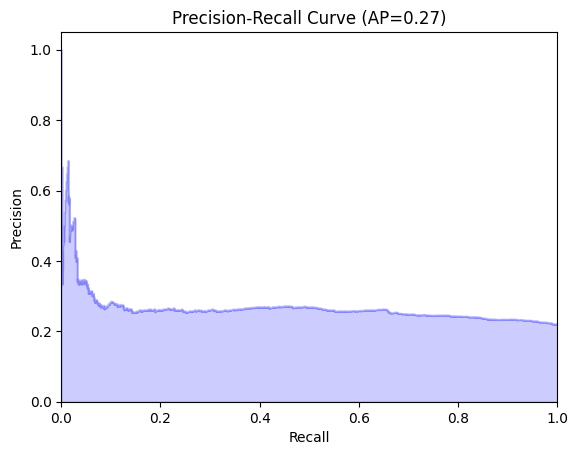

Average Precision: 0.27


In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Assuming you have true labels and predicted probabilities

# Compute precision and recall values
precision, recall, _ = precision_recall_curve(y_true,pred_proba)

# Calculate average precision
ap = average_precision_score(y_true,pred_proba)

# Plot precision-recall curve
plt.step(recall, precision, color='b', alpha=0.2, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (AP={:.2f})'.format(ap))
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

print('Average Precision: {:.2f}'.format(ap))


Score: 0.5715723188313787


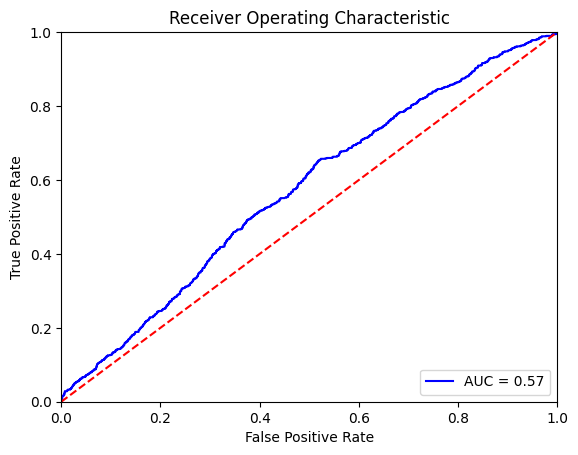

In [40]:
from sklearn.metrics import roc_auc_score, roc_curve, \
                            confusion_matrix , auc
fpr, tpr, threshold = roc_curve(y_true,pred_proba)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
print("Score: "+ str(roc_auc))
plt.show()

recall : 0.4649321266968326
precision : 0.2700394218134034
threshold : 0.24693817925302786
f1 score : 0.3416458852867831


/tmp/ipykernel_240/583084676.py:23: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax1.get_shared_x_axes().join(ax1, ax2,ax3)


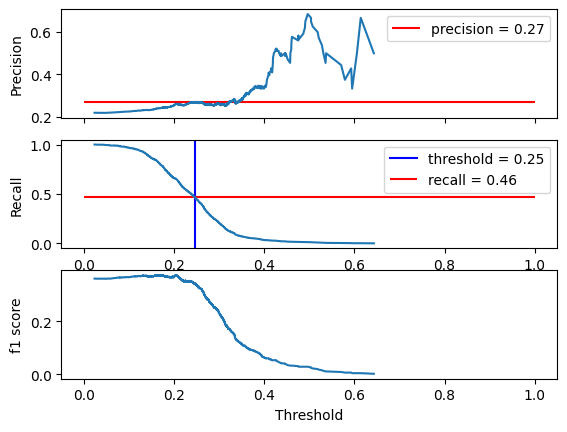

In [41]:
from sklearn.metrics import precision_recall_curve, f1_score

precision, recall, thresholds = precision_recall_curve(y_true, pred_proba)
precision = precision[:-1]
recall = recall[:-1]
f1_scores = 2*(precision*recall)/(precision + recall)
maxf = max(f1_scores)
min_index = [i for i, rec in enumerate(precision) if rec >= .27][0]
print(f'recall : {recall[min_index]}')
print(f'precision : {precision[min_index]}')
print(f'threshold : {thresholds[min_index]}')
print(f'f1 score : {f1_scores[min_index]}')
fig=plt.figure()
ax1 = plt.subplot(311)
ax2 = plt.subplot(312)
ax3 = plt.subplot(313)
ax1.hlines(y=precision[min_index],xmin=0, xmax=1, colors='red', label=f'precision = {precision[min_index]:.2f}')
ax2.axvline(thresholds[min_index], color='blue', label=f'threshold = {thresholds[min_index]:.2f}')
ax2.hlines(y=recall[min_index],xmin=0, xmax=1, colors='red', label=f'recall = {recall[min_index]:.2f}')
ax1.plot(thresholds,precision)
ax2.plot(thresholds,recall)
ax3.plot(thresholds,f1_scores)
ax1.get_shared_x_axes().join(ax1, ax2,ax3)
ax1.set_xticklabels([])
ax1.set_ylabel('Precision')
ax2.set_ylabel('Recall')
ax1.legend(loc='best')
ax2.legend(loc='best')
ax3.set_ylabel('f1 score')
plt.xlabel('Threshold')
plt.show()


In [44]:
used_threshold = 0.2589091068323581
threshold = 0.2480543623551904
Another_threshold = 0.24240653446164098
preds = [1 if pred > threshold else 0 for pred in pred_proba ]

In [45]:
precision = precision_score(y_true=y_true, y_pred=preds)
recall = recall_score(y_true=y_true, y_pred=preds)
f1 = f1_score(y_true=y_true, y_pred=preds)
print(f'precision = {precision}')
print(f'recall = {recall}')
print("F1 score:", f1)

precision = 0.2713903743315508
recall = 0.4592760180995475
F1 score: 0.34117647058823525


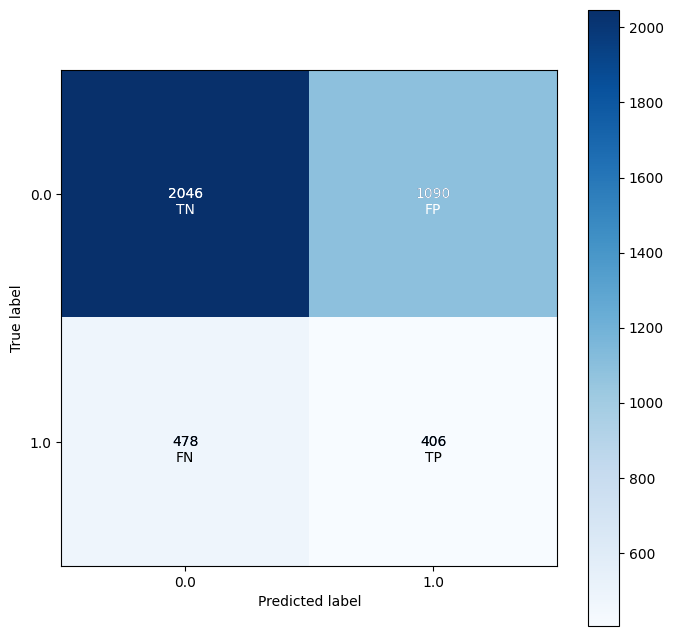

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

confmat = confusion_matrix(y_true=y_true, y_pred=preds)
disp = ConfusionMatrixDisplay(confusion_matrix=confmat,
                               display_labels=Pipe.classes_)

fig, ax = plt.subplots(figsize=(8, 8))
im = disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')

# add annotations to each square
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(j, i, f"\n{confmat[i, j]:d}\n"
                       f"{'TN' if i == j and i==0 else 'TP' if i== j and i ==1 else 'FP' if j > i else 'FN'}",
                ha="center", va="center", color="white" if confmat[i, j] > confmat.max() / 2 else "black")

plt.show()

# checking discrimination 

In [47]:
import numpy as np 
def verify_no_discrimination( X_test, y_true, y_pred, max_diff_tuple=0.05,max_diff_stations = .1 ,min_samples=30):
    """
    Verifies that no subdeparment has discrimination in between protected races
    """
    stations = X_test['station'].unique()
    gender_classes = X_test['Gender'].unique()
    ethnicity_classes = X_test['Officer-defined ethnicity'].unique()
    
    is_satisfied_tuple = True
    is_satisfied_stations = True
    problematic_stations = {}
    good_stations = {}
    ignored_stations = {}
    ignored_subgroups = []
    global_succes_rate = {}
    for station in stations:
        success_rates = {}
        for gender_class in gender_classes:
            for ethnicity_class in ethnicity_classes :
                mask = (X_test['Gender'] == gender_class) & (X_test['station'] == station) & (X_test['Officer-defined ethnicity'] == ethnicity_class)
                
                if np.sum(mask) > min_samples:
                    try :
                        rate = precision_score(y_true[mask], y_pred[mask], pos_label=1, zero_division=0)
                        if rate < .01:
                            ignored_subgroups.append({(station,gender_class,ethnicity_class):rate})
                            continue
                        success_rates[(gender_class,ethnicity_class)] = ( rate, np.sum(mask))
                    except ZeroDivisionError : 
                        print(station)
                        print(data[mask].isnull().sum())
        if len(success_rates) > 1:    
            diff = np.max(list(x[0] for x in success_rates.values())) - np.min(list(x[0] for x in success_rates.values()))
            global_succes_rate[station] = np.mean(list(x[0] for x in success_rates.values()))
            if diff > max_diff_tuple:
                is_satisfied_tuple = False
                problematic_stations[station]= (diff, success_rates)
            else:
                good_stations[station] =( diff, success_rates)
        else:
            ignored_stations[station]= (None, [])
        
    global_desparncey_score = np.max(list(global_succes_rate.values())) - np.min(list(global_succes_rate.values()))
    if global_desparncey_score > max_diff_stations:
        is_satisfied_stations = False
        
    return is_satisfied_tuple,is_satisfied_stations, problematic_stations, good_stations, global_desparncey_score,global_succes_rate,ignored_stations,ignored_subgroups



In [48]:
is_satisfied_tuple,is_satisfied_stations, problematic_stations, good_stations, global_desparncey_score,global_succes_rate,ignored_stations,ignored_subgroups = verify_no_discrimination(
    test_pred, y_true, y_pred,max_diff_tuple=.05,min_samples=60)

In [49]:
if not is_satisfied_tuple:
    print("Requirement failed 😢")
    print("Global rates: {}".format(global_desparncey_score))
    print("Num problematic departments: {}".format(len(problematic_stations)))
    print("Num good departments: {}".format(len(good_stations)))
    print("Num ignored departments: {} and it's {}".format(len(ignored_stations),ignored_stations))
    print("avg diff:", np.mean([p[0] for p in problematic_stations.values()]))
else:
    print("Requirement satisfied! 🚀")

print("Departments analysed: {}".format(len(problematic_stations) + len(good_stations)))        

Requirement failed 😢
Global rates: 0.11817650984317649
Num problematic departments: 1
Num good departments: 2
Num ignored departments: 3 and it's {'durham': (None, []), 'cambridgeshire': (None, []), 'bedfordshire': (None, [])}
avg diff: 0.24074074074074076
Departments analysed: 3


In [51]:
# import sqlite3
# conn = sqlite3.connect('prediction.db')
# cursor = conn.cursor()
# cursor.execute('select * from prediction')
# rows = cursor.fetchall()
